# **Importing Libraries**

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

#**Loading Model**

In [3]:
model=tf.keras.models.load_model('/content/trained_plant_disease_model.keras')

In [4]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     6,913,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,048,288 (133.70 MB)

 Trainable params: 11,682,762 (44.57 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 23,365,526 (89.13 MB)

#**Visualizing Image**

In [7]:
import kagglehub
import os

# 1. Download the dataset
print("Downloading dataset...")
dataset_path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
print(f"Dataset downloaded to: {dataset_path}")

# 2. Check the exact folder structure
# Kaggle datasets sometimes have nested folders when extracted.
print("Contents of the base folder:", os.listdir(dataset_path))

100%|██████████| 2.70G/2.70G [00:22<00:00, 126MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2
Contents of the base folder: ['new plant diseases dataset(augmented)', 'New Plant Diseases Dataset(Augmented)', 'test']


In [8]:
import os

# Create the path to the top-level test folder
test_dir_base = os.path.join(dataset_path, "test")

# Because Kaggle often double-nests folders, the images are usually inside "test/test"
test_dir = os.path.join(test_dir_base, "test")

print("Path to test images:", test_dir)

Path to test images: /root/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2/test/test


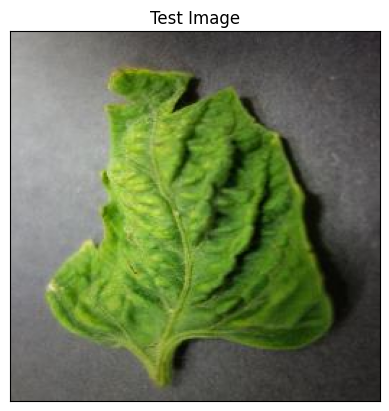

In [38]:
import cv2
image_path="/root/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2/test/test/TomatoYellowCurlVirus4.JPG"
img=cv2.imread(image_path)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #Covert BGR to RGB

plt.imshow(img)
plt.title("Test Image")
plt.xticks([])
plt.yticks([])
plt.show()

#**Preprocessing**

In [39]:
image=tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128))
input_arr=tf.keras.preprocessing.image.img_to_array(image)
input_arr=np.array([input_arr])#convert image to batch
print(input_arr.shape)

(1, 128, 128, 3)


In [40]:
prediction=model.predict(input_arr)
prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step


array([[1.06270797e-17, 2.12078511e-20, 5.11591203e-13, 2.13997792e-15,
        1.31284643e-15, 5.65976099e-14, 4.10725832e-19, 5.81007096e-17,
        1.81911968e-18, 1.18624162e-18, 1.72022085e-17, 3.23651343e-13,
        2.96879491e-14, 2.56877592e-12, 6.74327231e-17, 5.88214509e-14,
        2.13413154e-16, 4.26639701e-18, 1.73996883e-15, 2.09439254e-11,
        5.91063716e-20, 3.53780582e-17, 4.28199278e-14, 3.64739801e-11,
        1.74195370e-16, 4.98124017e-14, 3.10686264e-15, 3.76790192e-16,
        6.72319160e-08, 8.37106467e-14, 3.77026795e-12, 5.47184216e-15,
        1.96063377e-14, 1.19998395e-11, 1.75496000e-12, 9.99999881e-01,
        6.61900493e-13, 1.99735329e-13]], dtype=float32)

In [41]:
result_index=np.argmax(prediction)
result_index

np.int64(35)

In [42]:
class_name=['Apple___Apple_scab',
            'Apple___Black_rot',
            'Apple___Cedar_apple_rust',
            'Apple___healthy',
            'Blueberry___healthy',
            'Cherry_(including_sour)___Powdery_mildew',
            'Cherry_(including_sour)___healthy',
            'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
            'Corn_(maize)___Common_rust_',
            'Corn_(maize)___Northern_Leaf_Blight',
            'Corn_(maize)___healthy',
            'Grape___Black_rot',
            'Grape___Esca_(Black_Measles)',
            'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
            'Grape___healthy',
            'Orange___Haunglongbing_(Citrus_greening)',
            'Peach___Bacterial_spot',
            'Peach___healthy',
            'Pepper,_bell___Bacterial_spot',
            'Pepper,_bell___healthy',
            'Potato___Early_blight',
            'Potato___Late_blight',
            'Potato___healthy',
            'Raspberry___healthy',
            'Soybean___healthy',
            'Squash___Powdery_mildew',
            'Strawberry___Leaf_scorch',
            'Strawberry___healthy',
            'Tomato___Bacterial_spot',
            'Tomato___Early_blight',
            'Tomato___Late_blight',
            'Tomato___Leaf_Mold',
            'Tomato___Septoria_leaf_spot',
            'Tomato___Spider_mites Two-spotted_spider_mite',
            'Tomato___Target_Spot',
            'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
            'Tomato___Tomato_mosaic_virus',
            'Tomato___healthy']

#**Displaying Result**

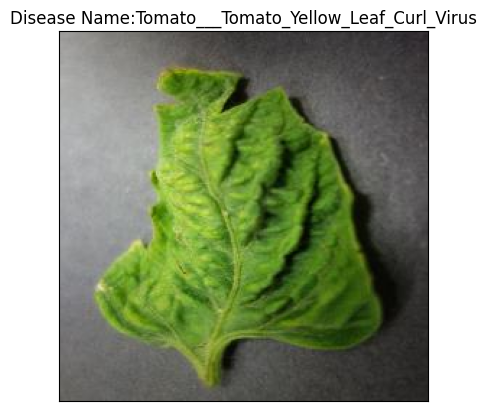

In [43]:
model_prediction=class_name[result_index]
plt.imshow(img)
plt.title(f"Disease Name:{model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()